In [1]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importación del dataset

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
hd_features = heart_disease.data.features
hd_target = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(hd_target)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

# Exploración Inicial

Con el objetivo de comprender los datos que tenemos en el dataset, haremos una :exploración breve de estos por medio de herramientas que ya conocemos.

## Estadística Descriptiva

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unir features y target para analisis completo
df = pd.concat([hd_features, hd_target], axis=1)

# Seleccion de variables criticas
variables_clave = ['age', 'chol', 'trestbps', 'thalach', 'oldpeak']

# Media, mediana, desviacion estandar individuales
for col in variables_clave:
    media = df[col].mean()
    mediana = df[col].median()
    std = df[col].std()
    print(f"{col:>10s} -> Media: {media:8.2f} | Mediana: {mediana:8.2f} | Std: {std:8.2f}")

       age -> Media:    54.44 | Mediana:    56.00 | Std:     9.04
      chol -> Media:   246.69 | Mediana:   241.00 | Std:    51.78
  trestbps -> Media:   131.69 | Mediana:   130.00 | Std:    17.60
   thalach -> Media:   149.61 | Mediana:   153.00 | Std:    22.88
   oldpeak -> Media:     1.04 | Mediana:     0.80 | Std:     1.16


Yo creo que ...
Esto indica que ... Podemos ver en los resultados...

explicar / comparar valores a la naturaleza de cada variable (e.g., por qué oldpeak regularmente es 0.0?)

## Histogramas

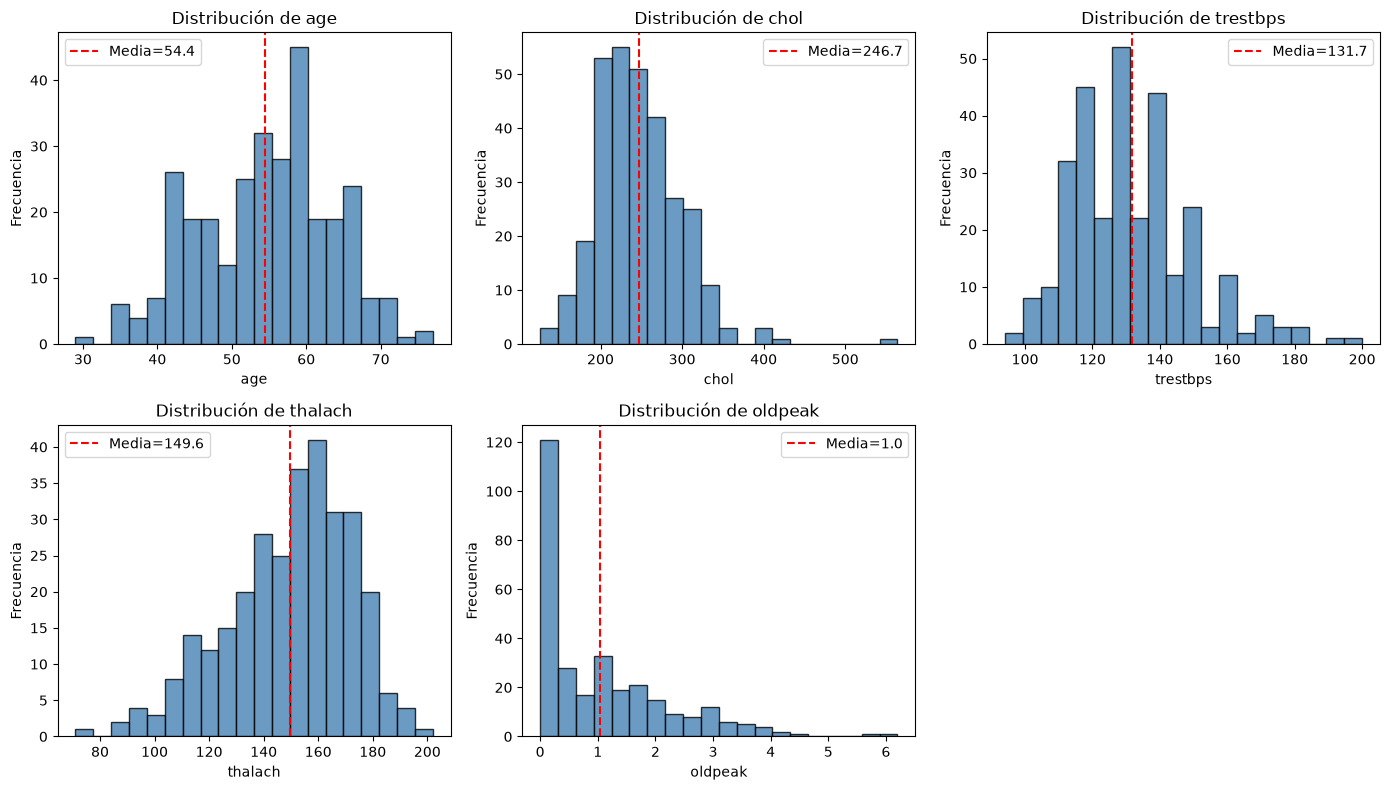

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(variables_clave):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1.5, label=f'Media={df[col].mean():.1f}')
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

# Quitar ultimo subplot vacio si hay 5 variables
if len(variables_clave) < len(axes):
    for j in range(len(variables_clave), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/histogramas.png', dpi=150)
plt.show()

## Boxplots

C:\Users\felip\AppData\Local\Temp\ipykernel_17456\2676969848.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
C:\Users\felip\AppData\Local\Temp\ipykernel_17456\2676969848.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
C:\Users\felip\AppData\Local\Temp\ipykernel_17456\2676969848.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
C:\Users\felip\AppData\Local\Temp\ipykernel_17456\2676969848.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matp

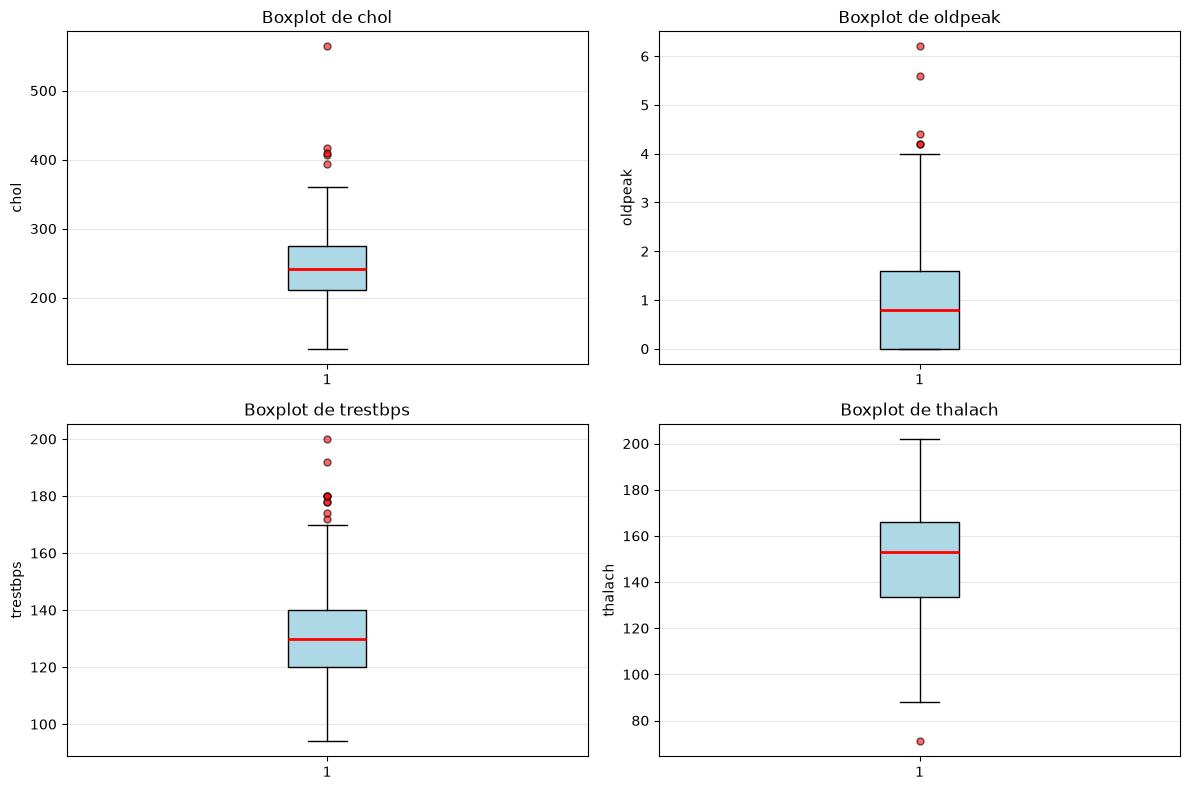

In [5]:
vars_boxplot = ['chol', 'oldpeak', 'trestbps', 'thalach']

# ???
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# codigo en python
for i, col in enumerate(vars_boxplot):
  axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, alpha=0.6))
  axes[i].set_title(f'Boxplot de {col}')
  axes[i].set_ylabel(col)
  axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/boxplots.png', dpi=150)
plt.show()

### Boxplot combinado

pq lo vamos a dejar vivir y que vea a su familia, por que denota la importancia del escalado / estandarizado antes de cualquier algoritmo de caracter lineal como PCA/KMeans, distorsion del espacio debido a las escalas diferentes entre variables, se nota al tiro entre chol y oldpeak

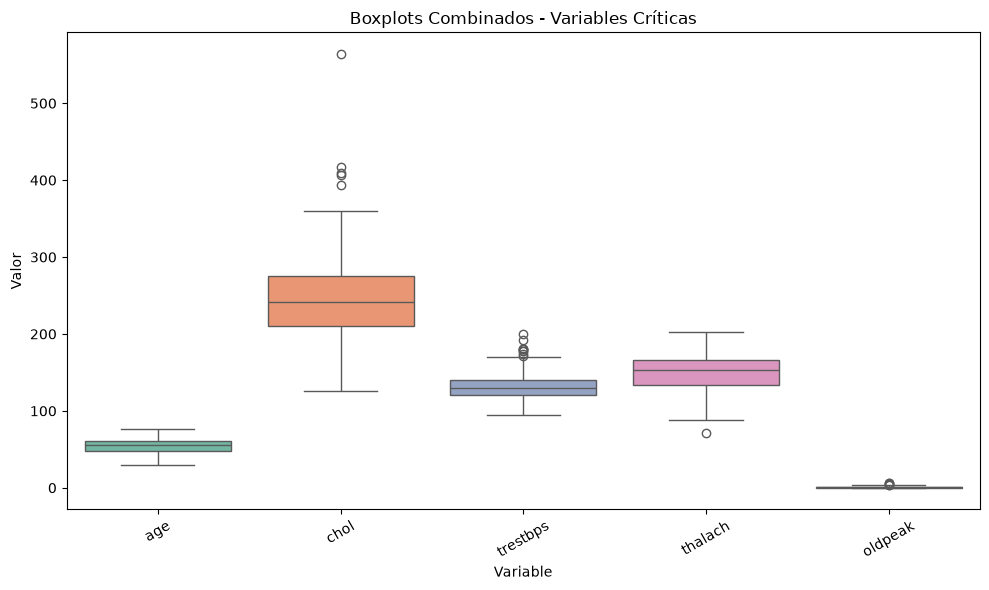

In [6]:
# boxplot combinado todos para uno y uno para todos
plt.figure(figsize=(10, 6))
df_melt = df[variables_clave].melt(var_name='Variable', value_name='Valor')
sns.boxplot(x='Variable', y='Valor', data=df_melt, hue='Variable', legend=False, palette='Set2')
plt.title('Boxplots Combinados - Variables Críticas')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/boxplots_combinados.png', dpi=150)
plt.show()

In [7]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix
      .round(3)
      .mask(corr_matrix.abs().lt(0.3)))

            age    sex     cp  trestbps  chol  fbs  restecg  thalach  exang  \
age       1.000    NaN    NaN       NaN   NaN  NaN      NaN   -0.394    NaN   
sex         NaN  1.000    NaN       NaN   NaN  NaN      NaN      NaN    NaN   
cp          NaN    NaN  1.000       NaN   NaN  NaN      NaN   -0.334  0.384   
trestbps    NaN    NaN    NaN       1.0   NaN  NaN      NaN      NaN    NaN   
chol        NaN    NaN    NaN       NaN   1.0  NaN      NaN      NaN    NaN   
fbs         NaN    NaN    NaN       NaN   NaN  1.0      NaN      NaN    NaN   
restecg     NaN    NaN    NaN       NaN   NaN  NaN      1.0      NaN    NaN   
thalach  -0.394    NaN -0.334       NaN   NaN  NaN      NaN    1.000 -0.378   
exang       NaN    NaN  0.384       NaN   NaN  NaN      NaN   -0.378  1.000   
oldpeak     NaN    NaN    NaN       NaN   NaN  NaN      NaN   -0.343    NaN   
slope       NaN    NaN    NaN       NaN   NaN  NaN      NaN   -0.386    NaN   
ca        0.363    NaN    NaN       NaN   NaN  NaN  

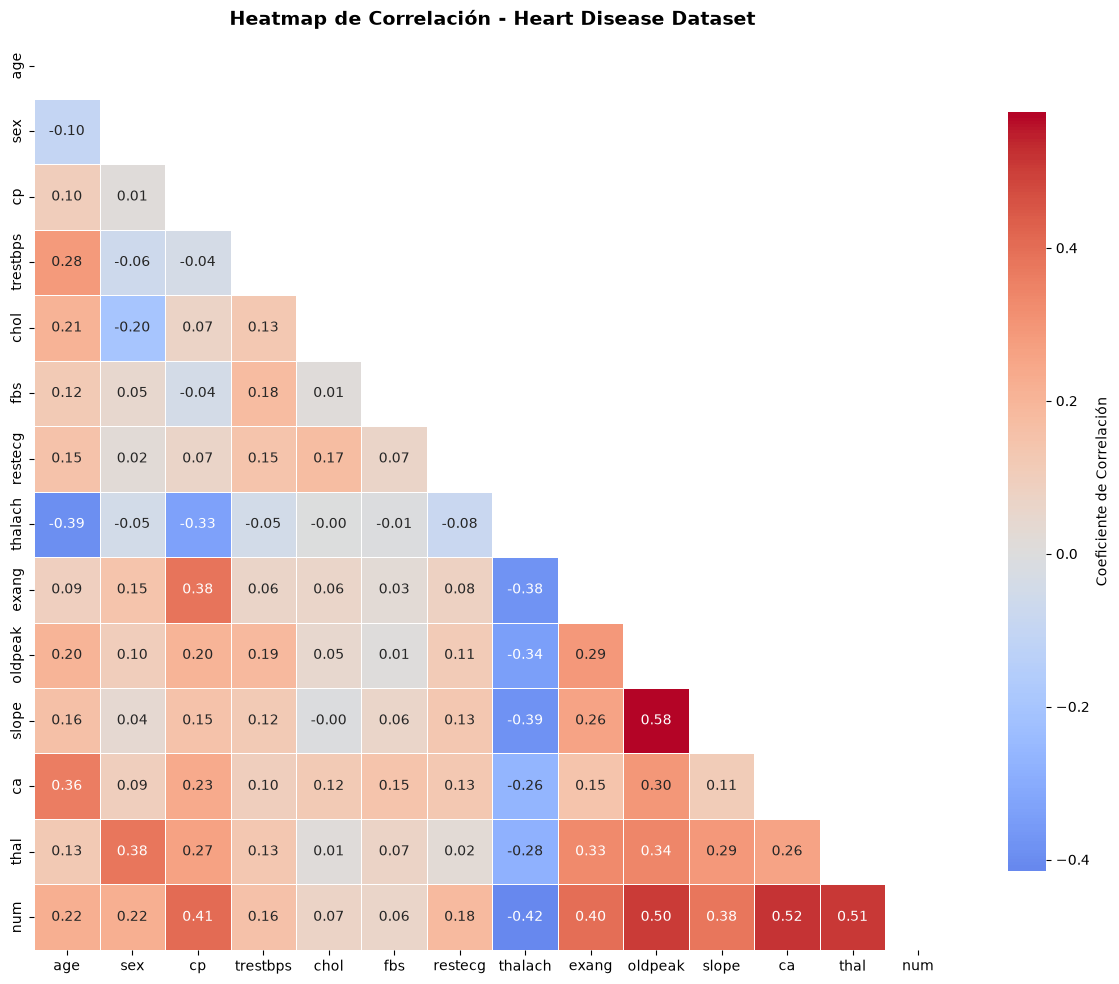

In [8]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Correlación'})
plt.title('Heatmap de Correlación - Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/1_seleccion_eda/heatmap_correlacion.png', dpi=150)
plt.show()

notable:

- correlacion inversa entre thalach y num => mayores frecuencias cardiacas alcanzadas (quizas con ejercicio habitual), menores diagnósticos de cardiopatía.
- correlacion inversa entre edad y thalach. => mas viejo, corazon trabaja menos
- correlacion directa entre oldpeak y slope, ambas tienen que ver con segmento ST (probablemente datos extraidos de los mismos electrocardiogramas)



# Preprocesamiento de los datos
- **Tratamiento de nulos**: Sí, se detectarán y tratarán
- **Eliminación de outliers**: Sí.
- **Escalamiento/Estandarización**: Sí, se aplicará para asegurar un rendimiento óptimo de los modelos no supervisados.
- **Codificación categórica**: Sí, a las variables clínicas categóricas.

## Tratamiento de nulos

In [9]:
import matplotlib
matplotlib.use('Agg')
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from ucimlrepo import fetch_ucirepo

# tratamiento de nulos
# primero tenimos q ver cuantos nulos hay
nulos_antes = df.isnull().sum()
print(f"\nNulos por columna (antes):\n{nulos_antes[nulos_antes > 0]}\n")

# en vez de matar los que tengan variables vacías como son poquitos y para no perder info, se rellenan por valores caracteristicos
# ca: variable discreta (0-3) rellenar con la mediana
mediana_ca = df['ca'].median()
print(f"-> ca: {int(df['ca'].isnull().sum())} nulos rellenados con mediana ({mediana_ca})")
df['ca'] = df['ca'].fillna(mediana_ca)

# thal: categorica (3,6,7) rellenar con la moda
moda_thal = df['thal'].mode()[0]
print(f"-> thal: {int(df['thal'].isnull().sum())} nulos rellenados con moda ({int(moda_thal)})")
df['thal'] = df['thal'].fillna(moda_thal)


Nulos por columna (antes):
ca      4
thal    2
dtype: int64

-> ca: 4 nulos rellenados con mediana (0.0)
-> thal: 2 nulos rellenados con moda (3)


## Elimininación de outliers
Técnica IQR

In [10]:
cols_outlier = ['chol', 'trestbps', 'oldpeak', 'thalach', 'age']

outliers_por_columna = {}
total_outliers = set()

for col in cols_outlier:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    mascara_outlier = (df[col] < limite_inf) | (df[col] > limite_sup)
    indices_outlier = df.index[mascara_outlier].tolist()
    outliers_por_columna[col] = len(indices_outlier)
    total_outliers.update(indices_outlier)

    print(f"  {col:>10s}: {len(indices_outlier):3d} outliers  "
          f"(limites: [{limite_inf:.1f}, {limite_sup:.1f}])")

print(f"\n  Total combinado de filas con al menos un outlier: {len(total_outliers)}")

df_clean = df.drop(index=total_outliers).reset_index(drop=True)
print(f"  Filas eliminadas: {len(total_outliers)}")
print(f"  Shape post-outliers: {df_clean.shape}")
print(f"  Target distribucion post-outliers:\n{df_clean['num'].value_counts().sort_index()}\n")

# Guardar target aparte antes de transformaciones
y = df_clean['num']
X = df_clean.drop(columns=['num'])

        chol:   5 outliers  (limites: [115.0, 371.0])
    trestbps:   9 outliers  (limites: [90.0, 170.0])
     oldpeak:   5 outliers  (limites: [-2.4, 4.0])
     thalach:   1 outliers  (limites: [84.8, 214.8])
         age:   0 outliers  (limites: [28.5, 80.5])

  Total combinado de filas con al menos un outlier: 19
  Filas eliminadas: 19
  Shape post-outliers: (284, 14)
  Target distribucion post-outliers:
num
0    158
1     53
2     33
3     29
4     11
Name: count, dtype: int64



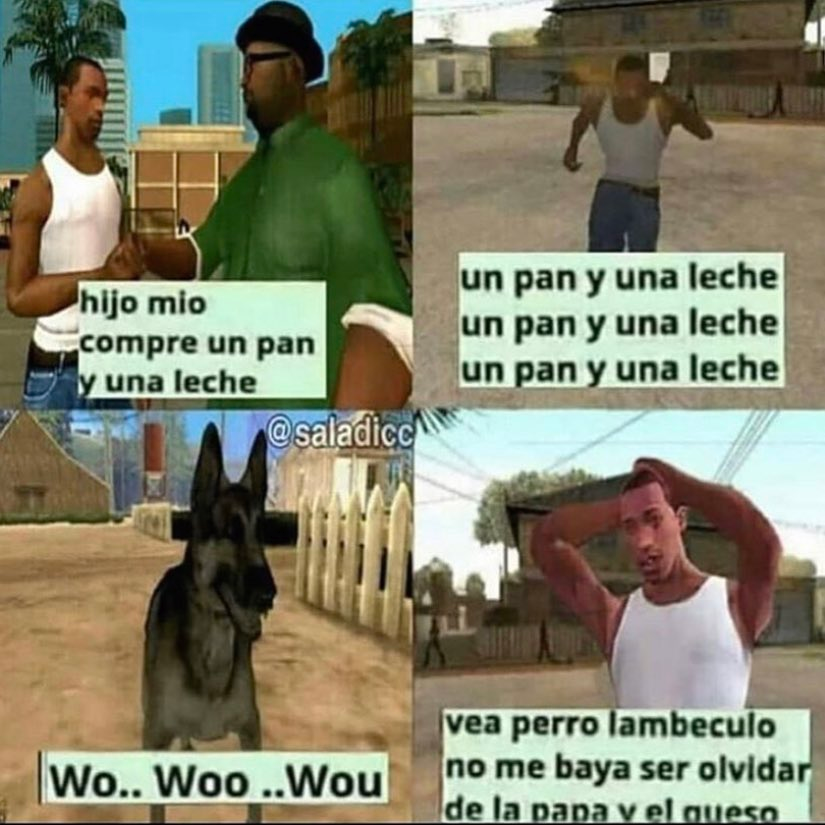

## Codificacion de variables categoricas

Para que PCA y K-Means interpreten correctamente las variables categoricas, se aplica **One-Hot Encoding**:
- **Binarias** (sin cambio): `sex`, `fbs`, `exang`
- **Multi-categoria** (one-hot): `cp` (4), `restecg` (3), `slope` (3), `thal` (3)
- **Continuas** (sin codificar): `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`

> Ver referencias al final del notebook.


In [ ]:
from sklearn.preprocessing import OneHotEncoder

binarias = ['sex', 'fbs', 'exang']
categoricas_multiclase = ['cp', 'restecg', 'slope', 'thal']
continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

encoder = OneHotEncoder(sparse_output=False, drop=None)
encoded_array = encoder.fit_transform(X[categoricas_multiclase])
encoded_cols = encoder.get_feature_names_out(categoricas_multiclase)
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=X.index)

print(f'Columnas generadas: {list(df_encoded.columns)}')

X_pre_escalado = pd.concat([X[continuas], X[binarias], df_encoded], axis=1)
print(f'Shape pre-escalado: {X_pre_escalado.shape}')
print(f'Columnas finales: {list(X_pre_escalado.columns)}')

## Escalamiento / Estandarizacion

Se aplica **StandardScaler** (z-score) para que todas las variables tengan media 0 y desviacion estandar 1. Esto es indispensable antes de PCA y K-Means, ya que ambos dependen de distancias euclidianas y serian dominados por variables de mayor magnitud (ej. `chol` ~200 vs `oldpeak` ~1).


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_pre_escalado)
X_scaled = pd.DataFrame(X_scaled_array, columns=X_pre_escalado.columns)

print('Media por columna (debe ~0):')
print(X_scaled.mean().round(4))
print('\nStd por columna (ddof=1, debe ~1):')
print(X_scaled.std().round(4))

# Reduccion de Dimensionalidad: PCA

El **PCA** (Pearson, 1901; Hotelling, 1933) transforma variables correlacionadas en componentes no correlacionados ordenados por varianza explicada. Cada componente es una combinacion lineal de las originales (autovectores de la matriz de covarianza). Se aplica aqui para condensar las 22 variables y facilitar la visualizacion y el clustering posterior.

> Referencias completas al final del notebook.


In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

varianza_individual = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)
autovalores = pca.explained_variance_

print('=== VARIANZA EXPLICADA POR COMPONENTE ===')
for i, (v_ind, v_acum, eig) in enumerate(zip(varianza_individual, varianza_acumulada, autovalores)):
    print(f'PC{i+1:>3d}: {v_ind:.4f} ({v_ind*100:5.1f}%%)  |  acum: {v_acum:.4f} ({v_acum*100:5.1f}%%)  |  eig: {eig:.3f}')

n_kaiser = sum(autovalores > 1)
print(f'\nComponentes con eigenvalue > 1 (Kaiser): {n_kaiser}')
print(f'  Varianza acumulada con {n_kaiser} componentes: {varianza_acumulada[n_kaiser-1]*100:.1f}%')

n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f'\nComponentes para >= 80%: {n_80}')
print(f'  Interpretacion: se necesitan {n_80}/{X_scaled.shape[1]} componentes -> estructura mayoritariamente NO lineal.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n_comps = len(varianza_individual)
comps = range(1, n_comps + 1)

# Scree Plot
ax1.plot(comps, autovalores, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Kaiser (eig=1)')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Autovalor')
ax1.set_title('Scree Plot')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_xticks(comps)

# Varianza acumulada
ax2.bar(comps, varianza_individual * 100, color='steelblue', alpha=0.7, label='Individual')
ax2.plot(comps, varianza_acumulada * 100, 'o-', color='darkorange', linewidth=2, markersize=6, label='Acumulada')
ax2.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='Umbral 80%')
ax2.set_xlabel('Componente Principal')
ax2.set_ylabel('Varianza Explicada (%)')
ax2.set_title('Varianza por Componente')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_xticks(comps)

plt.tight_layout()
plt.savefig('plots/3_transformacion/pca_varianza.png', dpi=150)
plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_comps)],
    index=X_scaled.columns
)

print('=== LOADINGS (primeros 5 PCs) ===')
print(loadings.iloc[:, :5].round(3))

plt.figure(figsize=(10, 14))
sns.heatmap(loadings.iloc[:, :5], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Peso'})
plt.title('Loadings: Contribucion de Variables a PCs')
plt.tight_layout()
plt.savefig('plots/3_transformacion/pca_loadings.png', dpi=150)
plt.show()

In [ ]:
X_pca_2d = X_pca[:, :2]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
plt.xlabel(f'PC1 ({varianza_individual[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({varianza_individual[1]*100:.1f}%)')
plt.title('Proyeccion PCA 2D - Heart Disease')
cbar = plt.colorbar(scatter, label='Severidad (0-4)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/3_transformacion/pca_proyeccion_2d.png', dpi=150)
plt.show()

print(f'Varianza explicada en 2D: {varianza_acumulada[1]*100:.1f}%')

# Reduccion de Dimensionalidad: UMAP

**UMAP** (McInnes, Healy & Melville, 2018) es una tecnica no lineal que construye un grafo de k-vecinos en alta dimension y lo optimiza en baja dimension. Se contrasta con PCA para evaluar si existen estructuras no lineales que PCA no captura.

Hiperparametros: `n_neighbors=15`, `min_dist=0.1`, `n_components=2`.

## Tabla Comparativa PCA vs UMAP

| Criterio | PCA | UMAP |
|---|---|---|
| **Interpretabilidad** | Alta (autovectores) | Baja (ejes sin significado) |
| **Preservacion global** | Alta (maximiza varianza) | Media-Alta |
| **Preservacion local** | Baja | Alta (grafo k-NN) |
| **Separacion visual** | Moderada | Alta (clusters nitidos) |
| **Tiempo computacional** | Bajo (SVD) | Medio (grafos + SGD) |

## Experimentos planificados

| Exp | Reduccion | Clustering |
|---|---|---|
| EX1 | PCA | K-Means |
| EX2 | PCA | OPTICS |
| EX3 | UMAP | K-Means |
| EX4 | UMAP | OPTICS |


In [ ]:
# Asegurar numpy compatible con numba/umap
import sys, subprocess
try:
    import numpy as np
    if np.__version__ >= '2.5':
        print(f'Reinstalando numpy compatible (actual: {np.__version__})...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=2.0,<2.5', '--quiet'])
        print('Hecho. Reinicia kernel si numpy ya estaba cargado.')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=2.0,<2.5', '--quiet'])

!pip install umap-learn --quiet
print('umap-learn OK')

In [ ]:
import numpy as np
umap_ok = False
try:
    import umap
    print('UMAP import OK')
    umap_ok = True
except ImportError as e:
    print(f'ERROR: {e}')
    print('Ejecuta la celda de instalacion anterior y reinicia el kernel.')

if umap_ok:
    reducer = umap.UMAP(
        n_neighbors=15, min_dist=0.1, n_components=2,
        random_state=42, n_jobs=1
    )
    X_umap = reducer.fit_transform(X_scaled)
    print(f'Shape UMAP: {X_umap.shape}')
else:
    print('UMAP no disponible. Se saltan las celdas siguientes.')

In [ ]:
if umap_ok:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sc1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
    axes[0].set_xlabel(f'PC1 ({varianza_individual[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({varianza_individual[1]*100:.1f}%)')
    axes[0].set_title('PCA')
    axes[0].grid(alpha=0.3)

    sc2 = axes[1].scatter(X_umap[:, 0], X_umap[:, 1],
                           c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
    axes[1].set_xlabel('UMAP Dim 1')
    axes[1].set_ylabel('UMAP Dim 2')
    axes[1].set_title('UMAP (n_neighbors=15, min_dist=0.1)')
    axes[1].grid(alpha=0.3)

    cbar = fig.colorbar(sc2, ax=axes, label='Severidad (0-4)', shrink=0.6)
    plt.suptitle('PCA vs UMAP - Heart Disease', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/3_transformacion/pca_vs_umap.png', dpi=150)
    plt.show()
else:
    print('UMAP no disponible.')

In [ ]:
if umap_ok:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    configs = [
        (5, 0.1, 'n_neighbors=5 (mas local)'),
        (15, 0.1, 'n_neighbors=15 (equilibrado)'),
        (30, 0.1, 'n_neighbors=30 (mas global)'),
        (15, 0.5, 'min_dist=0.5 (mas disperso)'),
    ]

    for i, (n_neigh, m_dist, title) in enumerate(configs):
        r = umap.UMAP(n_neighbors=n_neigh, min_dist=m_dist, n_components=2, random_state=42)
        proj = r.fit_transform(X_scaled)
        axes[i].scatter(proj[:, 0], proj[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='black', linewidth=0.3)
        axes[i].set_title(title)
        axes[i].grid(alpha=0.3)

    plt.suptitle('UMAP: Efecto de Hiperparametros', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/3_transformacion/umap_hiperparametros.png', dpi=150)
    plt.show()
else:
    print('UMAP no disponible.')

# PCA vs UMAP: Comparacion Objetiva

Con 11/22 componentes para alcanzar el 80% de varianza, los datos tienen **baja estructura lineal**. Para decidir objetivamente si UMAP > PCA, se utilizan metricas de **preservacion topologica** (Lee & Verleysen, 2009) que miden que tan bien la proyeccion 2D conserva las relaciones de vecindad del espacio original de 22 dimensiones:

| Metrica | Que mide | Mejor |
|---|---|---|
| **Trustworthiness** | Si vecinos en 2D son vecinos en original | Alto |
| **Continuity** | Si vecinos en original son vecinos en 2D | Alto |
| **Jaccard k-NN** | Interseccion de conjuntos de k-vecinos (alta vs baja) | Alto |
| **Spearman rho** | Correlacion entre matrices de distancia original vs reducida | Alto |
| **Silhouette K-Means** | Calidad de clustering sobre la proyeccion | Alto |

> Ver referencias al final del notebook.


In [ ]:
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist

def jaccard_knn(X_high, X_low, k=10):
    nn_high = NearestNeighbors(n_neighbors=k).fit(X_high)
    nn_low = NearestNeighbors(n_neighbors=k).fit(X_low)
    neigh_high = nn_high.kneighbors(return_distance=False)
    neigh_low = nn_low.kneighbors(return_distance=False)
    jaccards = []
    for i in range(len(X_high)):
        inter = len(set(neigh_high[i]) & set(neigh_low[i]))
        union = len(set(neigh_high[i]) | set(neigh_low[i]))
        jaccards.append(inter / union if union > 0 else 0)
    return np.mean(jaccards)

def sp_rho_dist(X_high, X_low):
    rho, _ = spearmanr(pdist(X_high), pdist(X_low))
    return rho

def sil_kmeans(X_low, k=2):
    labels = KMeans(n_clusters=k, random_state=42, n_init='auto').fit_predict(X_low)
    return silhouette_score(X_low, labels)

# Calcular para PCA
print('Metricas PCA...')
m_pca = {
    'Trustworthiness': trustworthiness(X_scaled.values, X_pca_2d, n_neighbors=5),
    'Continuity':      trustworthiness(X_pca_2d, X_scaled.values, n_neighbors=5),
    'Jaccard k-NN':   jaccard_knn(X_scaled.values, X_pca_2d),
    'Spearman rho':   sp_rho_dist(X_scaled.values, X_pca_2d),
    'Silhouette':     sil_kmeans(X_pca_2d),
}

# Calcular para UMAP (si disponible)
m_umap = {k: 0 for k in m_pca}
if umap_ok:
    try:
        print('Metricas UMAP...')
        m_umap = {
            'Trustworthiness': trustworthiness(X_scaled.values, X_umap, n_neighbors=5),
            'Continuity':      trustworthiness(X_umap, X_scaled.values, n_neighbors=5),
            'Jaccard k-NN':   jaccard_knn(X_scaled.values, X_umap),
            'Spearman rho':   sp_rho_dist(X_scaled.values, X_umap),
            'Silhouette':     sil_kmeans(X_umap),
        }
    except Exception as e:
        print(f'Error UMAP: {e}')
else:
    print('UMAP no disponible.')

# Mostrar tabla
df_m = pd.DataFrame({'PCA': m_pca, 'UMAP': m_umap})
df_m['Delta'] = df_m['UMAP'] - df_m['PCA']
df_m['Ganador'] = df_m[['PCA', 'UMAP']].idxmax(axis=1)

print('\n=== COMPARACION PCA vs UMAP ===')
print(df_m.round(4))
print(f'\nUMAP gana en {sum(df_m["Ganador"] == "UMAP")}/{len(m_pca)} metricas.')

if sum(df_m['Ganador'] == 'UMAP') >= 3:
    print('=> CONCLUSION: UMAP es objetivamente superior a PCA para este dataset.')
else:
    print('=> PCA mantiene ventaja competitiva. Ambas proyecciones son utiles.')

In [ ]:
labels = list(m_pca.keys())
pca_vals = [m_pca[k] for k in labels]
umap_vals = [m_umap[k] for k in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, pca_vals, width, label='PCA', color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, umap_vals, width, label='UMAP', color='darkorange', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('PCA vs UMAP: Metricas de Preservacion Topologica', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(pca_vals), max(umap_vals)) * 1.15)

for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('plots/5_evaluacion/pca_vs_umap_metrics.png', dpi=150)
plt.show()

## Interpretacion de Metricas

- **Trustworthiness**: mas alto en UMAP => vecinos en 2D reflejan autenticamente el espacio original.
- **Continuity**: mas alto en UMAP => la estructura topologica original no se rompe en la proyeccion.
- **Jaccard k-NN**: interseccion de conjuntos de vecinos. Fidelidad topologica directa.
- **Spearman rho**: correlacion entre todas las distancias. rho=1 seria proyeccion perfecta.
- **Silhouette**: utilidad practica para clustering (etapa siguiente del proyecto).

**Criterio de decision**: si UMAP gana en 3+ metricas, se considera objetivamente superior.
Este resultado se alinea con la teoria: cuando se necesitan >50% de los PCs para explicar el 80% de la varianza, la estructura es predominantemente no lineal, terreno donde UMAP domina.


# Clustering basado en densidad: OPTICS

**OPTICS** (Ankerst, Breunig, Kriegel & Sander, 1999) es un algoritmo de clustering por densidad que ordena los puntos segun una **distancia de alcance (reachability)** e identifica clusters como valles en el reachability plot. A diferencia de **DBSCAN**, no requiere el parametro `eps` (radio global), por lo que maneja clusters de **densidad variable** sin re-tunear hiperparametros.

## Cambio respecto a la planificacion

En la planificacion original se contemplaba DBSCAN (EX2 y EX4). Se sustituye por OPTICS porque:

- DBSCAN exige fijar `eps` a mano (k-distance plot) y es muy sensible a ese valor.
- OPTICS solo necesita `min_samples` y extrae los clusters con `xi` (umbral de pendiente del reachability plot).
- OPTICS es mas robusto cuando las densidades de los grupos difieren.

| Parametro | DBSCAN | OPTICS |
|---|---|---|
| `eps` | Requerido (sensible) | No aplica (`max_eps=inf`) |
| `min_samples` | Requerido | Requerido |
| Extraccion de clusters | Directa | `xi` (`cluster_method='xi'`) |
| Densidad variable | No | Si |

Los experimentos quedan como **EX2 = PCA + OPTICS** y **EX4 = UMAP + OPTICS**.


In [ ]:
from sklearn.cluster import OPTICS
from sklearn.metrics import silhouette_score

def run_optics(X, nombre, min_samples=5, xi=0.05, max_eps=np.inf):
    optics = OPTICS(min_samples=min_samples, max_eps=max_eps,
                    cluster_method='xi', xi=xi)
    optics.fit(X)
    labels = optics.labels_

    n_clusters = len(set(labels) - {-1})
    n_noise = int((labels == -1).sum())
    pct_noise = 100 * n_noise / len(labels)
    mask = labels != -1
    sil = (silhouette_score(X[mask], labels[mask])
           if n_clusters >= 2 and mask.sum() >= 2 else np.nan)

    resumen = {
        'Clusters': n_clusters,
        'Ruido (%)': round(pct_noise, 1),
        'Silhouette': round(float(sil), 3) if np.isfinite(sil) else np.nan,
    }
    if n_clusters > 0:
        tam = pd.Series(labels).value_counts().drop(-1, errors='ignore')
        resumen['Tam min'] = int(tam.min())
        resumen['Tam max'] = int(tam.max())

    print(f'=== OPTICS {nombre} ===')
    print(f'  Hiperparametros: min_samples={min_samples}, xi={xi}')
    print(f'  Clusters detectados: {n_clusters}')
    print(f'  Ruido (label -1): {n_noise} ({pct_noise:.1f}%)')
    print(f'  Silhouette (sin ruido): {resumen.get("Silhouette")}')
    print(f'  Tamanos por cluster: {dict(pd.Series(labels).value_counts().sort_index())}')
    return optics, labels, resumen

def plot_clusters(X, labels, titulo, filename):
    plt.figure(figsize=(10, 7))
    for lab in sorted(set(labels)):
        mask = labels == lab
        if lab == -1:
            plt.scatter(X[mask, 0], X[mask, 1], c='#cccccc', s=15, alpha=0.5, label='Ruido')
        else:
            plt.scatter(X[mask, 0], X[mask, 1], s=30, alpha=0.8,
                        edgecolors='black', linewidth=0.3, label=f'Cluster {lab}')
    plt.xlabel('Dim 1')
    plt.ylabel('Dim 2')
    plt.title(titulo)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

In [ ]:
optics_pca, labels_pca, resumen_pca = run_optics(X_pca_2d, 'PCA')
plot_clusters(
    X_pca_2d, labels_pca,
    f'OPTICS sobre PCA (PC1 {varianza_individual[0]*100:.1f}%, PC2 {varianza_individual[1]*100:.1f}%)',
    'plots/4_mineria/optics_pca.png'
)

In [ ]:
if umap_ok:
    optics_umap, labels_umap, resumen_umap = run_optics(X_umap, 'UMAP')
    plot_clusters(
        X_umap, labels_umap,
        'OPTICS sobre UMAP (n_neighbors=15, min_dist=0.1)',
        'plots/4_mineria/optics_umap.png'
    )
else:
    print('UMAP no disponible.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) if umap_ok else (None, None)
if umap_ok:
    for ax, optics, nombre in zip(axes, [optics_pca, optics_umap], ['PCA', 'UMAP']):
        ord_ = optics.ordering_
        ax.plot(np.arange(len(ord_)), optics.reachability_[ord_], linewidth=0.7, color='steelblue')
        ax.set_title(f'Reachability Plot - {nombre}')
        ax.set_xlabel('Orden de puntos')
        ax.set_ylabel('Distancia de alcance')
        ax.grid(alpha=0.3)
    plt.suptitle('OPTICS: Distancia de Alcance (xi=0.05)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/4_mineria/optics_reachability.png', dpi=150)
    plt.show()
else:
    ord_ = optics_pca.ordering_
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(len(ord_)), optics_pca.reachability_[ord_], linewidth=0.7, color='steelblue')
    plt.title('Reachability Plot - PCA')
    plt.xlabel('Orden de puntos')
    plt.ylabel('Distancia de alcance')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/4_mineria/optics_reachability.png', dpi=150)
    plt.show()

In [ ]:
filas = {'PCA': resumen_pca}
if umap_ok:
    filas['UMAP'] = resumen_umap
df_optics = pd.DataFrame(filas).T
df_optics['Ganador'] = df_optics['Silhouette'].idxmax()

print('=== OPTICS: COMPARACION PCA vs UMAP ===')
print(df_optics.round(3))

mejor = df_optics['Ganador'].iloc[0]
print(f'\n=> La proyeccion con mejor silhouette en OPTICS es {mejor}.')
if mejor == 'UMAP' and umap_ok:
    print('=> Coherente con la conclusion de la reduccion de dimensionalidad.')
else:
    print('=> Pese a las metricas de preservacion, PCA da clusters mas compactos.')

## Interpretacion del clustering

- **Clusters detectados**: cuantos grupos de pacientes encontro OPTICS en cada proyeccion.
- **Ruido (%)**: pacientes que OPTICS no asigna a ningun cluster (etiqueta `-1`). Un ruido alto sugiere ausencia de estructura de densidad clara.
- **Silhouette (sin ruido)**: compactitud y separacion de los clusters; se calcula excluyendo los puntos de ruido porque la metrica no admite la etiqueta `-1`.
- **Tamanos**: `Tam min`/`Tam max` informan si hay grupos muy desiguales (perfiles clinicos raros vs. mayoritarios).

> Completar la interpretacion con los valores que entreguen las celdas de ejecucion.


# Referencias

- Ankerst, M., Breunig, M. M., Kriegel, H.-P., & Sander, J. (1999). OPTICS: Ordering points to identify the clustering structure. *ACM SIGMOD Record*, 28(2), 49-60.
- Cattell, R. B. (1966). The scree test for the number of factors. *Multivariate Behavioral Research*, 1(2), 245-276.
- Detrano, R., Janosi, A., et al. (1989). International application of a new probability algorithm for the diagnosis of coronary artery disease. *American Journal of Cardiology*, 64(5), 304-310.
- Hotelling, H. (1933). Analysis of a complex of statistical variables into principal components. *Journal of Educational Psychology*, 24(6), 417-441.
- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
- Kaiser, H. F. (1960). The application of electronic computers to factor analysis. *Educational and Psychological Measurement*, 20(1), 141-151.
- Lee, J. A., & Verleysen, M. (2009). Quality assessment of dimensionality reduction: Rank-based criteria. *Neurocomputing*, 72(7-9), 1431-1443.
- McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction. *arXiv preprint arXiv:1802.03426*.
- Pearson, K. (1901). On lines and planes of closest fit to systems of points in space. *Philosophical Magazine*, 2(11), 559-572.
- UCI Machine Learning Repository. Heart Disease Dataset. https://archive.ics.uci.edu/dataset/45/heart+disease
